## Load data and packages

In [1]:
import numpy as np
import pandas as pd   # We import Pandas!
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn import linear_model
import torch
import itertools

import pyro
from pyro.infer.autoguide import AutoNormal
import pyro.distributions as dist
from pyro.contrib.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from pyro.infer import MCMC, NUTS, HMC, SVI, Trace_ELBO
from pyro.optim import Adam, ClippedAdam

# fix random generator seed (for reproducibility of results)
np.random.seed(42)

# matplotlib options
palette = itertools.cycle(sns.color_palette())
plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 10)

In [2]:
df_train= pd.read_csv('../data/movies_with_genres_and_cast_train.csv')
df_test= pd.read_csv('../data/movies_with_genres_and_cast_test.csv')

#To test different ranges, must be higher than 1969
Start_year = 2000
df_train=df_train[df_train["year"] >= Start_year]
df_test=df_test[df_test["year"] >= Start_year]

# Sub Models

The final model is split up into 4 submodels

## Model 1: Release date, genres and budget regression model

The first model is a very simple regression model. In this first model, we will use as features the day of release within a year, the genres, and the budget of the movie.
As for all of the other models, the target variable is the inflated movie revenue y.

Since we use four different models, it is easier to direcly split the data table into the train set and test set. This will also ensure comparable results. For this reason, the preparation of the data will be done for both the train and test sets.

### Prepare features and target variable

The first feature is $X_{time}$. This feature will reflect the influence of the day of the year on the revenue of the movie. Since revenue is not a linear function of the days of the year, we will 1-of-K encoding to allow non-linear relationship. However, 1-of-K encoding with all of the days would mean 365 dummies, and it won't be relevant to showcase the influence of a period of the year. Instead, weeks and days of the week (dow) are selected.

In [3]:
X_time_train = np.concatenate([pd.get_dummies(df_train[x]).astype(float) for x in ["dow", "week"]], axis=1)
X_time_test = np.concatenate([pd.get_dummies(df_test[x]).astype(float) for x in ["dow", "week"]], axis=1)
print(X_time_train.shape, X_time_test.shape)
print(X_time_train[1])

(1706, 60) (2846, 60)
[0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


The second feature is the $X_{movie}$. It will regroup all of the caracteristics of the movies that are considered here. This includes the genres of the movie, as well as the inflated budget. 

Only the 10 most occuring genres are considered here, and each movie can have none, as well as multiple genres within those. For the 10 genre dummies, the value in the data table is $\frac{1}{\text{Number of genre of the movie}}$ if the movie is of this genre, or 0 if not. This will permit a higher weight for the movies with a low number of genre.

In [4]:
movie_caracteristics = ["genre_drama" , "genre_comedy" , "genre_thriller",
 "genre_romance", "genre_action", "genre_horror", "genre_crime",
 "genre_documentary", "genre_adventure", "genre_science_fiction", "budget_inflated"]

X_movie_train = df_train[movie_caracteristics].copy()
X_movie_test = df_test[movie_caracteristics].copy()

X_movie_train = X_movie_train.apply(pd.to_numeric, errors='coerce')
X_movie_test = X_movie_test.apply(pd.to_numeric, errors='coerce')

# Convert to numpy
X_movie_train = X_movie_train.values
X_movie_test = X_movie_test.values

print(X_movie_train.shape)
print(X_movie_test.shape)
print(X_movie_train[1])

(1706, 11)
(2846, 11)
[0.00000000e+00 1.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 2.00375766e+07]


Once this is done, we can concatenate $X_{time}$ and $X_{movie}$ in the final vector $X$ that will be used in the model, and we can standardize it based on the training set mean.

In [5]:
X_train = np.concatenate([X_time_train, X_movie_train], axis=1)
X_test = np.concatenate([X_time_test, X_movie_test], axis=1)
print(X_train.shape)
print(X_test.shape)


(1706, 71)
(2846, 71)


In [6]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_train = (X_train - X_mean) / X_std
X_test = (X_test - X_mean) / X_std


The target variable $y$ is also prepared and standardized for both the training and test set.

In [7]:
y_train = df_train["revenue_inflated"].values
y_test = df_test["revenue_inflated"].values

y_mean = y_train.mean()
y_std = y_train.std()
y_train = (y_train - y_mean) / y_std
y_test = (y_test - y_mean) / y_std

### Test and error mesurement

To mesure the errors of the model, we create a function that will be able to compute the corrcoef, MAE, RMSE, and R².

In [8]:
def compute_error(trues, predicted):
    corr = np.corrcoef(predicted, trues)[0,1]
    mae = np.mean(np.abs(predicted - trues))
    rmse = np.sqrt(np.mean((predicted - trues)**2))
    r2 = max(0, 1 - np.sum((trues-predicted)**2) / np.sum((trues - np.mean(trues))**2))
    return corr, mae, rmse, r2

First, we try a linear regression from Sklearn.

In [9]:
#regr = linear_model.LinearRegression()
regr = linear_model.Ridge()
regr.fit(X_train, y_train)
y_hat = regr.predict(X_test)

# Convert back to the original scale
y_pred = y_hat * y_std + y_mean
y_true = y_test * y_std + y_mean

corr, mae, rmse, r2 = compute_error(y_true, y_pred)
print("CorrCoef: %.3f\nMAE: %.3f\nRMSE: %.3f\nR2: %.3f" % (corr, mae, rmse, r2))

CorrCoef: 0.769
MAE: 82402110.206
RMSE: 166653896.310
R2: 0.575


### MODEL 1

The model is a basic linear regression model. A gaussian distribution was selected since it makes sense that the revenues of the films over time follows a normal distribution. An intercept $\alpha$ was explicitly modelled with a prior of 0 since everything is standardized. A regression coefficient $\beta$ and a constant variance $\sigma$ were also implemented. The target variable then follows this distribution:

$y \sim \mathcal{N}(\alpha + \beta^T x_n, \sigma^2)$

In [10]:
def release_genre_budget_model(X, obs=None):
    alpha = pyro.sample("alpha", dist.Normal(0, 1))                   
    beta  = pyro.sample("beta", dist.Normal(torch.zeros(X.shape[1]), 
                                            torch.ones(X.shape[1])).to_event())    
    sigma = pyro.sample("sigma", dist.HalfCauchy(0.5)) 
    
    with pyro.plate("data"):
        y = pyro.sample("y", dist.Normal(alpha + X.matmul(beta), sigma), obs=obs)
        
    return y

### Stochastic variational inference (SVI) training

To train this model on the data, we will use stochastic variational inference (SVI) on the training set. First, we transform the data into pytorch tensors.

In [11]:
# Prepare data for Pyro model
X_train_torch = torch.tensor(X_train).float()
y_train_torch = torch.tensor(y_train).float()
X_test_torch = torch.tensor(X_test).float()
y_test_torch = torch.tensor(y_test).float()

Then, we automatically define the function used to approximate.

In [12]:
# Define guide function
guide = AutoMultivariateNormal(release_genre_budget_model)

# Reset parameter values
pyro.clear_param_store()

We set the number of steps and the learning rate of the optimizer, trying different values.

In [13]:
# Define the number of optimization steps
n_steps = 1000

# Setup the optimizer
adam_params = {"lr": 0.001} # learning rate (lr) of optimizer
optimizer = ClippedAdam(adam_params)

# Setup the inference algorithm
elbo = Trace_ELBO(num_particles=1)
svi = SVI(release_genre_budget_model, guide, optimizer, loss=elbo)

Now that everything is ready, we can create a loop that will compute the evidence lower bound (ELBO) each time and make it converge.

In [14]:
# Do gradient steps
for step in range(n_steps):
    elbo = svi.step(X_train_torch, y_train_torch)
    if step % 100 == 0:
        print("[%d] ELBO: %.1f" % (step, elbo))

[0] ELBO: 22785.5
[100] ELBO: 12385.2
[200] ELBO: 5342.7
[300] ELBO: 5206.8
[400] ELBO: 3490.6
[500] ELBO: 2789.7
[600] ELBO: 2601.7
[700] ELBO: 2595.6
[800] ELBO: 2468.3
[900] ELBO: 2454.3


Once we have the convergence of the ELBO, we can use the Predictive function from pyro.infer to retrieve the values of the inferred parameters $\alpha$, $\beta$ and $\sigma$.

In [15]:
from pyro.infer import Predictive

predictive = Predictive(release_genre_budget_model, guide=guide, num_samples=5000,
                        return_sites=("alpha", "beta", "sigma", "y"))
samples = predictive(X_train_torch, y_train_torch)
print(samples["alpha"].shape)


alpha_samples = samples["alpha"].detach().numpy()
beta_samples = samples["beta"].detach().numpy()
sigma_samples = samples["sigma"].detach().numpy()


torch.Size([5000, 1])


In [16]:
predictive = Predictive(release_genre_budget_model, guide=guide, num_samples=5000,
                        return_sites=("alpha", "beta", "sigma", "y"))
samples = predictive(X_train_torch)
print(samples["alpha"].shape)

y_mean_model1_train = samples["y"].mean(dim=0)
y_std_model1_train = samples["y"].std(dim=0)

torch.Size([5000, 1])


In [17]:
predictive = Predictive(release_genre_budget_model, guide=guide, num_samples=5000,
                        return_sites=("alpha", "beta", "sigma", "y"))

samples = predictive(X_test_torch)
y_mean_model1_test = samples["y"].mean(dim=0)
y_std_model1_test = samples["y"].std(dim=0)

Once we have the inferred parameters, we can comput $\hat{y}$, the standardized prediction. Then, we convert it back to the original scale.

In [18]:
y_hat = np.mean(alpha_samples.T + np.dot(X_test, beta_samples[:,0].T), axis=1)

y_pred = y_hat * y_std + y_mean
y_true = y_test * y_std + y_mean

print(y_pred.size)

2846


With the true value of the test set, and the predicted value, we can calculate the errors that we have. We will also compute a baseline for both the MAE and RMSE.

In [19]:
corr, mae, rmse, r2 = compute_error(y_true, y_pred)
print("CorrCoef: %.3f\nMAE: %.3f\nRMSE: %.3f\nR2: %.3f" % (corr, mae, rmse, r2))

y_true = torch.tensor(y_true).float()

baseline_pred = torch.zeros_like(y_true)
baseline_mae = torch.mean(torch.abs(baseline_pred - y_true))
baseline_rmse = torch.sqrt(torch.mean((baseline_pred - y_true) ** 2))
print("Baseline MAE: %.3f\nBaseline RMSE: %.3f" % (baseline_mae, baseline_rmse))

CorrCoef: 0.766
MAE: 83543173.901
RMSE: 167257115.085
R2: 0.572
Baseline MAE: 117953048.000
Baseline RMSE: 281523520.000


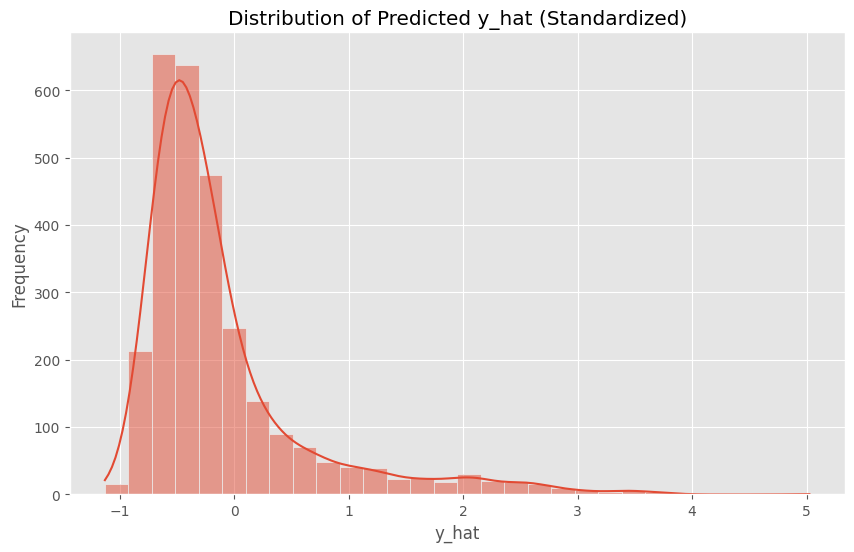

In [20]:
# Plot the distribution of y_hat
plt.figure(figsize=(10, 6))
sns.histplot(y_hat, kde=True, bins=30)
plt.title('Distribution of Predicted y_hat (Standardized)')
plt.xlabel('y_hat')
plt.ylabel('Frequency')
plt.show()

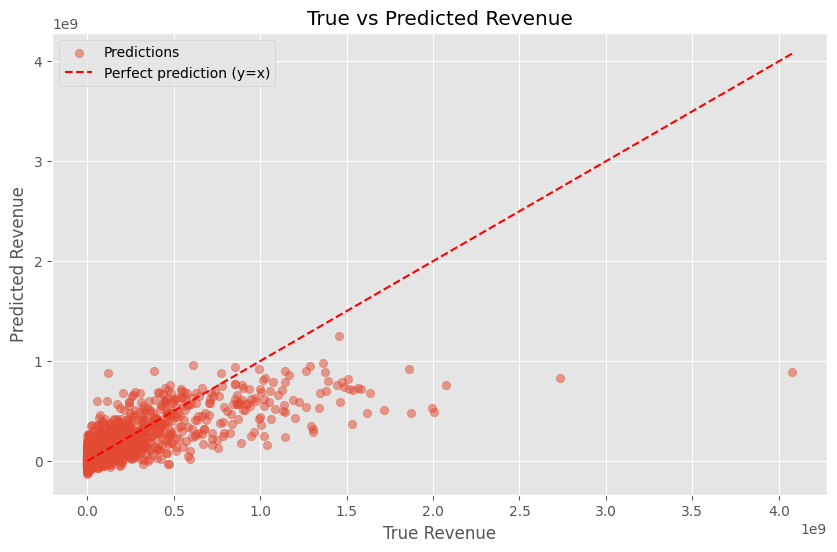

In [21]:
# Plot true vs predicted revenue with regression line
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.5, label='Predictions')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Perfect prediction (y=x)')
plt.xlabel('True Revenue')
plt.ylabel('Predicted Revenue')
plt.title('True vs Predicted Revenue')
plt.legend()
plt.show()

## Model 2: Actor genre model

In [22]:
data = pd.concat([df_train, df_test], ignore_index=True)
K=10 #number of genres
threshold =  10 # Number of movies an actor must have been in to be included in the model


### Data handling

Some main ides of this model requers that a model spesefik data handler is mad
1. actors and genra is siperatet so the kan be used as two difrent inputs
2. actors are filterd so we only use actors that have been seen X amount of times, this if a better prior were used this cuold be avoided
3. a impact is found to see the impact of each actore that is just the the movies revenue - the mean revanue 
4. a one row per actor per movie is made to train the model instet of one row per movie


In [23]:
def filter_actors(data, threshold):
    # Combine all actor columns into a single series
    all_actors = pd.concat([data[f'Actor_{i}'] for i in range(1, 6)])
    
    # Count occurrences of each actor
    actor_counts = all_actors.value_counts()
    
    # Filter actors based on the threshold
    valid_actors = actor_counts[actor_counts >= threshold].index
    
    # Replace invalid actors with NaN
    for i in range(1, 6):
        data[f'Actor_{i}'] = data[f'Actor_{i}'].where(data[f'Actor_{i}'].isin(valid_actors), other=pd.NA)
    
    return data

def expand_actor_rows(actors_batch, genres_batch, revenue_batch, impact_batch):
    actor_rows = []
    genre_rows = []
    revenue_rows = []
    impact_rows = []

    for actors, genres, revenue, impact in zip(
        actors_batch, genres_batch, revenue_batch, impact_batch
    ):
        for actor in actors:
            if actor != 0:
                actor_rows.append(actor)
                genre_rows.append(genres)
                revenue_rows.append(revenue)
                impact_rows.append(impact)

    return (
        torch.stack(actor_rows),
        torch.stack(genre_rows),
        torch.stack(revenue_rows),
        torch.stack(impact_rows),
    )

def preprocess_data(data, unique_actors, K=10, mean_revenue=None ):
    actor_cols = ["Actor_1", "Actor_2", "Actor_3", "Actor_4", "Actor_5"]
    genre_cols=data.columns[12:12+K+1]

    # 0 is reserved for missing/unknown actor
    actor_map = {old_id: new_id for new_id, old_id in enumerate(unique_actors, start=1)}
    actor_map[0] = 0
    # Number of actors including missing actor 0
    n_actors = len(actor_map)

    data[actor_cols] = data[actor_cols].fillna(0)
    data[actor_cols] = data[actor_cols].replace(actor_map)

    actor_ids = torch.tensor(data[actor_cols].values, dtype=torch.long)
    genre_matrix = torch.tensor(data[genre_cols].values, dtype=torch.float32)
    log_revenue = torch.tensor(np.log1p(data["revenue_inflated"].values), dtype=torch.float32)
    log_impact = log_revenue - mean_revenue
    return actor_ids, genre_matrix, log_revenue, log_impact


In [24]:
actor_cols = ["Actor_1", "Actor_2", "Actor_3", "Actor_4", "Actor_5"]

# Get all unique actor IDs except 0
unique_actors = pd.unique(data[actor_cols].values.ravel())
unique_actors = [a for a in unique_actors if a != 0]

train_log_revenue = torch.tensor(np.log1p(df_train["revenue_inflated"].values), dtype=torch.float32)

#split data into actors, genres, revenue and impact for train and test set 
#impact is defined as log_revenue - mean_log_revenue, where mean_log_revenue is the mean log revenue of the training set. This is done to center the revenue around 0 and make it easier for the model to learn the effects of actors and genres on the revenue.
train_actors, train_genres, train_revenue, train_impact = preprocess_data(df_train, unique_actors, K, train_log_revenue.mean())
test_actors, test_genres, test_revenue, test_impact = preprocess_data(df_test, unique_actors, K, train_log_revenue.mean())


#creat dataset with one row per actor, where the genre, revenue and impact of the movie are repeated for each actor. 
#This is done to allow the model to learn the effects of actors on the revenue and impact, while controlling for the genre of the movie.
train_actor, train_genrev2, train_revenuev2, train_impactv2 = expand_actor_rows(train_actors, train_genres, train_revenue, train_impact)
test_actor, test_genrev2, test_revenuev2, test_impactv2 = expand_actor_rows(test_actors, test_genres, test_revenue, test_impact)


#the number of actors in the training set
num_train_actors = int(train_actor.max().item()) + 1

train_actor = train_actor.long()
train_genrev2 = train_genrev2.float()
train_impactv2 = train_impactv2.float()

### The pyro model
This model predicts an outcome for each actor using an actor-specific baseline effect and actor-specific genre effects. Each actor has a general effect, while the genre vector determines how that actor’s genre preferences contribute to the prediction.

For actor $a_i$ with genre vector $g_i$:

$$
y_i \sim \mathcal{N}(\mu_i, \sigma)
$$

$$
\mu_i = \alpha_{a_i} + g_i^\top \beta_{a_i}
$$

Priors:

$$
\alpha_a \sim \mathcal{N}(0, \tau_\alpha)
$$

$$
\beta_{a,k} \sim \mathcal{N}(0, \tau_\beta)
$$

$$
\tau_\alpha, \tau_\beta, \sigma \sim \text{HalfCauchy}(5)
$$

where $\alpha_a$ is the actor baseline effect and $\beta_{a,k}$ is the genre-specific-actor effect.

In [25]:

#This model is build to learn on one actor per row not movie
def actor_genre_model(genre_matrix, actor_id, num_actors, obs=None):
    actor_id = actor_id.long()

    N, num_genres = genre_matrix.shape

    actor_scale = pyro.sample("actor_scale", dist.HalfCauchy(5.0))

    actor_effect = pyro.sample(
        "actor_effect",
        dist.Normal(
            torch.zeros(num_actors, device=genre_matrix.device),
            actor_scale * torch.ones(num_actors, device=genre_matrix.device)
        ).to_event(1)
    )

    actor_genre_scale = pyro.sample("actor_genre_scale", dist.HalfCauchy(5.0))

    actor_genre_effect = pyro.sample(
        "actor_genre_effect",
        dist.Normal(
            torch.zeros(num_actors, num_genres, device=genre_matrix.device),
            actor_genre_scale * torch.ones(num_actors, num_genres, device=genre_matrix.device)
        ).to_event(2)
    )

    sigma = pyro.sample("sigma", dist.HalfCauchy(5.0))


    # Handle unseen actors safely
    # Actor 0 is reserved as padding/no-actor; valid actors are 1 to num_actors-1
    # num_actors should equal max(actor_id) + 1 from training data
    known_actor_mask = (actor_id > 0) & (actor_id < num_actors)
    safe_actor_id = actor_id.clone()
    safe_actor_id[~known_actor_mask] = 0

    actor_part = actor_effect[safe_actor_id]
    actor_part = torch.where(
        known_actor_mask,
        actor_part,
        torch.zeros_like(actor_part)
    )

    interaction_part = (
        genre_matrix * actor_genre_effect[safe_actor_id]
    ).sum(dim=1)

    interaction_part = torch.where(
        known_actor_mask,
        interaction_part,
        torch.zeros_like(interaction_part)
    )
    mu =  actor_part + interaction_part

    with pyro.plate("data", N):
        y = pyro.sample("y", dist.Normal(mu, sigma), obs=obs)

    return y


### Train using SVD

The parameter store is cleared before training to remove any previous learned values.

The model is trained using stochastic variational inference (SVI). An `AutoNormal` guide is used to automatically approximate the posterior distribution, while the Adam optimizer updates the variational parameters.

Training runs for 1000 steps with a learning rate of `0.01`. During training, the loss is printed every 250 steps to monitor progress.

In [26]:
pyro.clear_param_store()

guide = AutoNormal(actor_genre_model)

optimizer = Adam({"lr": 0.01})

svi = SVI(
    actor_genre_model,
    guide,
    optimizer,
    loss=Trace_ELBO()
)

num_steps = 1000

for step in range(num_steps):
    loss = svi.step(
        train_genrev2,
        train_actor,
        num_train_actors,
        train_impactv2
    )

    if step % 250 == 0:
        print(f"step {step} loss = {loss:.2f}")

step 0 loss = 128220.82
step 250 loss = 22370.13
step 500 loss = 21837.71
step 750 loss = 21814.81


### posterior_samples

The test data is converted to the correct tensor types before prediction.

A baseline prediction is also created using the mean outcome from the training data. This provides a simple reference model where every test observation is predicted to have the same value.

A `Predictive` object is used to draw 500 posterior predictive samples from the trained model and guide. The model returns samples for the predicted outcome `y`, the actor effects, the actor-genre effects, and the noise parameter `sigma`.

The predicted values are summarized by computing the mean and standard deviation of the posterior predictive samples. The mean gives the expected prediction, while the standard deviation represents predictive uncertainty. The model predictions can then be compared against the training-mean baseline.

This is tested on row wise predictions

In [27]:
test_actor = test_actor.long()
test_genrev2 = test_genrev2.float()
test_impactv2 = test_impactv2.float()

predictive = Predictive(
    actor_genre_model,
    guide=guide,
    num_samples=500,
    return_sites=("y",'actor_genre_effect', "actor_effect",  "sigma")
)

posterior_samples = predictive(
    test_genrev2,
    test_actor,
    num_train_actors,
    obs=None
)

y_samples = posterior_samples["y"]
y_mean = y_samples.mean(dim=0)
y_std = y_samples.std(dim=0)

In [28]:
# Predictions from Bayesian model
y_samples = posterior_samples["y"]
y_mean = y_samples.mean(dim=0)
y_std = y_samples.std(dim=0)

# True values
y_true = test_impactv2

# Model metrics
model_mae = torch.mean(torch.abs(y_mean - y_true))
model_rmse = torch.sqrt(torch.mean((y_mean - y_true) ** 2))

# Baseline: predict 0 for every occurrence
baseline_pred = torch.zeros_like(y_true)

baseline_mae = torch.mean(torch.abs(baseline_pred - y_true))
baseline_rmse = torch.sqrt(torch.mean((baseline_pred - y_true) ** 2))

# Improvement
mae_improvement = baseline_mae - model_mae
rmse_improvement = baseline_rmse - model_rmse

mae_improvement_pct = 100 * mae_improvement / baseline_mae
rmse_improvement_pct = 100 * rmse_improvement / baseline_rmse

print("Model MAE:", model_mae.item())
print("Baseline MAE:", baseline_mae.item())
print("MAE improvement:", mae_improvement.item())
print("MAE improvement %:", mae_improvement_pct.item())

print()

print("Model RMSE:", model_rmse.item())
print("Baseline RMSE:", baseline_rmse.item())
print("RMSE improvement:", rmse_improvement.item())
print("RMSE improvement %:", rmse_improvement_pct.item())

Model MAE: 2.4495701789855957
Baseline MAE: 2.4666783809661865
MAE improvement: 0.01710820198059082
MAE improvement %: 0.693572461605072

Model RMSE: 3.2603089809417725
Baseline RMSE: 3.267515182495117
RMSE improvement: 0.0072062015533447266
RMSE improvement %: 0.22054071724414825


For each movie, the first valid actor is selected by ignoring actor IDs equal to `0`, which are treated as padding or missing actors. If a movie has no valid actors, actor `0` is used as a fallback.

The selected actor IDs and genre features are converted to the correct tensor types before prediction.

A `Predictive` object is then used to generate posterior predictive samples from the trained actor-genre model. Predictions are made for both the test set and the training set using 1000 samples.

For the training set, the posterior predictive samples of `y` are summarized by computing their mean and standard deviation. These values are saved so they can be used later as features in the stacked aggregate model.

In [29]:
valid_mask = test_actors != 0

# Find the first nonzero actor index per movie.
first_nonzero_idx = valid_mask.int().argmax(dim=1)
has_valid_actor = valid_mask.any(dim=1)

first_actor = [test_actors[i, first_nonzero_idx[i]] if has_valid_actor[i] else 0 for i in range(test_actors.shape[0])]
first_actor_tensor = torch.tensor(first_actor)

first_actor_tensor = first_actor_tensor.long()
test_genres = test_genres.float()
test_impact = test_impact.float()

predictive = Predictive(
    actor_genre_model,
    guide=guide,
    num_samples=1000,
    return_sites=("y",'actor_genre_effect', "actor_effect",  "sigma")
)

posterior_samples = predictive(
    test_genres,
    first_actor_tensor,
    num_train_actors,
    obs=None
)


valid_mask = train_actors != 0

# Find the first nonzero actor index per movie.
first_nonzero_idx = valid_mask.int().argmax(dim=1)
has_valid_actor = valid_mask.any(dim=1)

first_actor = [train_actors[i, first_nonzero_idx[i]] if has_valid_actor[i] else 0 for i in range(train_actors.shape[0])]
first_actor_tensor = torch.tensor(first_actor)

first_actor_tensor = first_actor_tensor.long()
train_genres = train_genres.float()

posterior_samples_train = predictive(
    train_genres,
    first_actor_tensor,
    num_train_actors,
    obs=None
)

# save train to use to train acrigade model
y_samples_train = posterior_samples_train["y"]
y_mean_model2_train = y_samples_train.mean(dim=0)
y_std_model2_train = y_samples_train.std(dim=0)



In [30]:
# Predictions from Bayesian model
y_samples = posterior_samples["y"]
y_mean_model2_test = y_samples.mean(dim=0)
y_std_model2_test = y_samples.std(dim=0)

# True values
y_true = test_impact

# Model metrics
model_mae = torch.mean(torch.abs(y_mean_model2_test - y_true))
model_rmse = torch.sqrt(torch.mean((y_mean_model2_test - y_true) ** 2))

# Baseline: predict 0 for every occurrence
baseline_pred = torch.zeros_like(y_true)

baseline_mae = torch.mean(torch.abs(baseline_pred - y_true))
baseline_rmse = torch.sqrt(torch.mean((baseline_pred - y_true) ** 2))

# Improvement
mae_improvement = baseline_mae - model_mae
rmse_improvement = baseline_rmse - model_rmse

mae_improvement_pct = 100 * mae_improvement / baseline_mae
rmse_improvement_pct = 100 * rmse_improvement / baseline_rmse

print("Model MAE:", model_mae.item())
print("Baseline MAE:", baseline_mae.item())
print("MAE improvement:", mae_improvement.item())
print("MAE improvement %:", mae_improvement_pct.item())

print()

print("Model RMSE:", model_rmse.item())
print("Baseline RMSE:", baseline_rmse.item())
print("RMSE improvement:", rmse_improvement.item())
print("RMSE improvement %:", rmse_improvement_pct.item())

Model MAE: 2.481891393661499
Baseline MAE: 2.5167694091796875
MAE improvement: 0.03487801551818848
MAE improvement %: 1.3858247995376587

Model RMSE: 3.3369908332824707
Baseline RMSE: 3.3533477783203125
RMSE improvement: 0.016356945037841797
RMSE improvement %: 0.48777955770492554


## Model 3: Market State Dynamic Regression LDS for Group Ensemble (No Log)

This notebook is the **ensemble-ready** version of our market-state dynamic regression LDS. The purpose is to keep the temporal Bayesian model we developed, while making its outputs directly compatible with the shared group aggregation workflow.

The main idea is simple: internally, the model is fitted on `revenue_inflated`, so the target is already adjusted for inflation inside the model. For aggregation with the other group models, the final posterior predictions are then converted back to **nominal `revenue`** by dividing by the movie-year inflation factor and exported in a CSV file.

Compared with the temporal reference notebook, this version changes the data interface and output format, but keeps the same overall LDS structure.


In [31]:
torch.set_default_dtype(torch.float32)
train_df=df_train.copy()
test_df=df_test.copy()

GENRE_COLUMNS = [
    'genre_drama',
    'genre_comedy',
    'genre_thriller',
    'genre_romance',
    'genre_action',
    'genre_horror',
    'genre_crime',
    'genre_documentary',
    'genre_adventure',
    'genre_science_fiction',
    'other_genre',
]


for frame in (train_df, test_df):
    frame['release_date'] = pd.to_datetime(frame['release_date'])
    frame['year'] = frame['year'].astype(int)
    frame['budget_missing_base'] = frame['budget_inflated'] <= 0
    frame['dominant_genre'] = frame[GENRE_COLUMNS].idxmax(axis=1)

train_df['is_train'] = True
test_df['is_train'] = False
full_df = pd.concat([train_df, test_df], ignore_index=True).copy()

full_df['revenue_deflator_raw'] = np.where(full_df['revenue'] > 0, full_df['revenue_inflated'] / full_df['revenue'], np.nan)
full_df['budget_deflator_raw'] = np.where(full_df['budget'] > 0, full_df['budget_inflated'] / full_df['budget'], np.nan)
year_to_deflator = {}
for year, group in full_df.groupby("year", sort=True):
    rev_median = group['revenue_deflator_raw'].median()
    bud_median = group['budget_deflator_raw'].median()
    if pd.notna(rev_median):
        year_to_deflator[int(year)] = float(rev_median)
    elif pd.notna(bud_median):
        year_to_deflator[int(year)] = float(bud_median)
    else:
        raise ValueError(f"No inflation factor could be derived for year {year}")

full_df['inflation_factor'] = full_df['year'].map(year_to_deflator).astype(float)
train_df = full_df[full_df["is_train"]].copy()
test_df = full_df[~full_df["is_train"]].copy()

print('train shape:', train_df.shape)
print('test shape :', test_df.shape)
print('train years:', int(train_df['year'].min()), '-', int(train_df['year'].max()))
print('test years :', int(test_df['year'].min()), '-', int(test_df['year'].max()))
print('missing budgets train:', int(train_df['budget_missing_base'].sum()))
print('missing budgets test :', int(test_df['budget_missing_base'].sum()))

train_df.head()

train shape: (1706, 41)
test shape : (2846, 41)
train years: 2000 - 2007
test years : 2008 - 2017
missing budgets train: 344
missing budgets test : 778


,budget,id,popularity,release_date,revenue,runtime,vote_average,vote_count,doy,year,...,month_sin,month_cos,log_revenue_inflated,log_budget_inflated,budget_missing_base,dominant_genre,is_train,revenue_deflator_raw,budget_deflator_raw,inflation_factor
0,0.0,46119.0,5.062928,2000-01-01,26394.0,100.0,6.1,14.0,1.0,2000,...,0.5,0.866025,10.780627,0.000000,True,genre_drama,True,1.821598,NaN,1.821598
1,11000000.0,10471.0,10.065450,2000-01-12,59827328.0,98.0,6.5,145.0,12.0,2000,...,0.5,0.866025,18.506687,16.813120,False,genre_comedy,True,1.821598,1.821598,1.821598
2,90000000.0,10384.0,5.496624,2000-01-14,14828081.0,91.0,4.9,109.0,14.0,2000,...,0.5,0.866025,17.111747,18.915034,False,genre_thriller,True,1.821598,1.821598,1.821598
3,10000000.0,2360.0,5.139550,2000-01-24,26330482.0,93.0,6.3,115.0,24.0,2000,...,0.5,0.866025,17.685952,16.717810,False,genre_comedy,True,1.821598,1.821598,1.821598
4,0.0,22230.0,9.916094,2000-01-25,688510.0,110.0,7.1,41.0,25.0,2000,...,0.5,0.866025,14.042000,0.000000,True,genre_comedy,True,1.821598,NaN,1.821598


### Data Setup

We use the **shared group split** directly from the tracked CSV files: one training set and one test set. This means the notebook is aligned with the same rows that the other group members will use in their own models and in the final aggregation notebook.

Even though the split itself is not purely temporal, the LDS still uses **year** as the internal time index. In other words, the observation rows come from the shared train/test files, while the latent market state and dynamic coefficients still evolve one year at a time.

We also preserve the original row order from the test file, since this is important when predictions from several models are combined later.


### Preprocessing

The main preprocessing choice in this notebook is how we handle movies with `budget_inflated <= 0`. We treat these budgets as missing rather than real zero-budget films.

The handling is the same `Impute+Flag` strategy selected earlier:

- detect missing budgets from `budget_inflated <= 0`
- impute `budget_inflated` using **training data only**
- use fallback order: same year + dominant genre, then same year, then global train median
- add a binary `budget_missing` indicator as an extra static feature

We also include `runtime` as an additional static feature. Runtime is imputed on the raw scale using training data only and then standardized from training statistics only, in the same spirit as the budget preprocessing.

After imputation, we standardize the inflation-adjusted budget feature, runtime, and the internal target using training-set statistics only. This is done for numerical stability during inference, not to change the meaning of the variables.


In [32]:
BASE_STATIC_COLUMNS = ['month_sin', 'month_cos']
TARGET_COLUMN = 'revenue_inflated'


def impute_budget(row, year_genre_medians, year_medians, global_median):
    key = (int(row['year']), row['dominant_genre'])
    if key in year_genre_medians:
        return year_genre_medians[key], 'year_genre'

    year = int(row['year'])
    if year in year_medians:
        return year_medians[year], 'year'

    return global_median, 'global'


train_valid_budget = train_df[~train_df['budget_missing_base']].copy()
global_budget_median = float(train_valid_budget['budget_inflated'].median())
year_budget_medians = train_valid_budget.groupby('year')['budget_inflated'].median().to_dict()
year_genre_budget_medians = train_valid_budget.groupby(['year', 'dominant_genre'])['budget_inflated'].median().to_dict()

full_df['budget_missing'] = 0
full_df['budget_imputation_strategy'] = 'observed'

fallback_counts = {'year_genre': 0, 'year': 0, 'global': 0}
missing_mask = full_df['budget_missing_base']
imputed_values = []
imputation_labels = []

for _, row in full_df.loc[missing_mask].iterrows():
    value, label = impute_budget(row, year_genre_budget_medians, year_budget_medians, global_budget_median)
    imputed_values.append(value)
    imputation_labels.append(label)
    fallback_counts[label] += 1

full_df.loc[missing_mask, 'budget_inflated'] = imputed_values
full_df.loc[missing_mask, 'budget_missing'] = 1
full_df.loc[missing_mask, 'budget_imputation_strategy'] = imputation_labels

train_df = full_df[full_df["is_train"]].copy()
test_df = full_df[~full_df["is_train"]].copy()

for frame in (full_df, train_df, test_df):
    frame['runtime_missing_base'] = frame['runtime'].isna() | (frame['runtime'] <= 0)

train_valid_runtime = train_df[~train_df['runtime_missing_base']].copy()
global_runtime_median = float(train_valid_runtime['runtime'].median())
runtime_missing_mask = full_df['runtime_missing_base']
full_df.loc[runtime_missing_mask, 'runtime'] = global_runtime_median

train_df = full_df[full_df["is_train"]].copy()
test_df = full_df[~full_df["is_train"]].copy()

DYNAMIC_COLUMNS = ['budget_inflated_std', *GENRE_COLUMNS]
STATIC_COLUMNS = [*BASE_STATIC_COLUMNS, 'budget_missing', 'runtime_std']

budget_mean = train_df['budget_inflated'].mean()
budget_std = train_df['budget_inflated'].std()
if budget_std == 0:
    budget_std = 1.0

y_mean = train_df[TARGET_COLUMN].mean()
y_std = train_df[TARGET_COLUMN].std()
if y_std == 0:
    y_std = 1.0

runtime_mean = train_df['runtime'].mean()
runtime_std = train_df['runtime'].std()
if runtime_std == 0:
    runtime_std = 1.0

for frame in (full_df, train_df, test_df):
    frame['budget_inflated_std'] = (frame['budget_inflated'] - budget_mean) / budget_std
    frame['runtime_std'] = (frame['runtime'] - runtime_mean) / runtime_std
    frame['y_std'] = (frame[TARGET_COLUMN] - y_mean) / y_std

years = np.arange(int(full_df["year"].min()), int(full_df["year"].max()) + 1)
year_to_idx = {year: idx for idx, year in enumerate(years)}

X_dyn_full_np = full_df[DYNAMIC_COLUMNS].to_numpy()
X_static_full_np = full_df[STATIC_COLUMNS].to_numpy()
y_full_std_np = full_df["y_std"].to_numpy()
year_idx_full_np = full_df["year"].map(year_to_idx).to_numpy()
obs_mask_np = full_df["is_train"].to_numpy().astype(bool)
test_mask_np = ~obs_mask_np
inflation_factor_full_np = full_df["inflation_factor"].to_numpy(dtype=float)

X_dyn_full = torch.tensor(X_dyn_full_np, dtype=torch.float32)
X_static_full = torch.tensor(X_static_full_np, dtype=torch.float32)
y_full_std = torch.tensor(y_full_std_np, dtype=torch.float32)
year_idx_full = torch.tensor(year_idx_full_np, dtype=torch.long)
obs_mask = torch.tensor(obs_mask_np, dtype=torch.bool)

print('imputation fallback counts:', fallback_counts)
print('full horizon years:', int(years[0]), '-', int(years[-1]), '(', len(years), 'years )')
print('dynamic coefficient dimension:', X_dyn_full_np.shape[1])
print('static coefficient dimension :', X_static_full_np.shape[1])
print('global budget median (train raw inflated scale):', round(global_budget_median, 4))
print('runtime imputed rows:', int(runtime_missing_mask.sum()))
print('global runtime median (train raw scale):', round(global_runtime_median, 4))


imputation fallback counts: {'year_genre': 339, 'year': 5, 'global': 778}
full horizon years: 2000 - 2017 ( 18 years )
dynamic coefficient dimension: 12
static coefficient dimension : 4
global budget median (train raw inflated scale): 40920855.0153
runtime imputed rows: 21
global runtime median (train raw scale): 104.0


### Baselines and Metrics

We keep two simple baselines for reference:

- a **mean baseline**, which predicts the training-set mean for every movie
- a **static regression baseline**, which uses the same observed features but no temporal dynamics

The notebook reports two kinds of metrics:

- **inflation-adjusted revenue metrics** for internal LDS diagnostics
- **nominal revenue metrics** for comparison with the other group models

The second set is the important one for aggregation and report comparison. Since the runtime-enabled variants performed best in the ablation study, runtime is now part of the comparison here as well.


In [33]:
def evaluate_inflated_predictions(y_true_inflated, y_pred_inflated, label):
    y_true_inflated = np.asarray(y_true_inflated)
    y_pred_inflated = np.asarray(y_pred_inflated)

    rmse_inflated = np.sqrt(np.mean((y_true_inflated - y_pred_inflated) ** 2))
    mae_inflated = np.mean(np.abs(y_true_inflated - y_pred_inflated))
    ss_res = np.sum((y_true_inflated - y_pred_inflated) ** 2)
    ss_tot = np.sum((y_true_inflated - y_true_inflated.mean()) ** 2)
    r2_inflated = 1.0 - ss_res / ss_tot

    metrics = {
        'rmse_inflated': rmse_inflated,
        'mae_inflated': mae_inflated,
        'r2_inflated': r2_inflated,
    }

    print(label)
    for key, value in metrics.items():
        print(f'  {key}: {value:.4f}')
    return metrics


def evaluate_revenue_predictions(y_true_revenue, y_pred_revenue, label):
    y_true_revenue = np.asarray(y_true_revenue)
    y_pred_revenue = np.asarray(y_pred_revenue)

    rmse = np.sqrt(np.mean((y_true_revenue - y_pred_revenue) ** 2))
    mae = np.mean(np.abs(y_true_revenue - y_pred_revenue))
    ss_res = np.sum((y_true_revenue - y_pred_revenue) ** 2)
    ss_tot = np.sum((y_true_revenue - y_true_revenue.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot

    metrics = {
        'rmse_revenue': rmse,
        'mae_revenue': mae,
        'r2_revenue': r2,
    }

    print(label)
    for key, value in metrics.items():
        print(f'  {key}: {value:.4f}')
    return metrics


train_true_revenue = train_df["revenue"].to_numpy()
test_true_revenue = test_df["revenue"].to_numpy()
train_inflation_factor = train_df["inflation_factor"].to_numpy()
test_inflation_factor = test_df["inflation_factor"].to_numpy()

mean_train_pred_inflated = np.full(len(train_df), y_mean)
mean_test_pred_inflated = np.full(len(test_df), y_mean)
mean_train_pred_revenue = mean_train_pred_inflated / train_inflation_factor
mean_test_pred_revenue = mean_test_pred_inflated / test_inflation_factor

mean_train_log_metrics = evaluate_inflated_predictions(train_df[TARGET_COLUMN], mean_train_pred_inflated, 'Mean baseline on train (inflation-adjusted revenue scale)')
mean_test_log_metrics = evaluate_inflated_predictions(test_df[TARGET_COLUMN], mean_test_pred_inflated, 'Mean baseline on test (inflation-adjusted revenue scale)')
mean_train_revenue_metrics = evaluate_revenue_predictions(train_true_revenue, mean_train_pred_revenue, 'Mean baseline on train (nominal revenue)')
mean_test_revenue_metrics = evaluate_revenue_predictions(test_true_revenue, mean_test_pred_revenue, 'Mean baseline on test (nominal revenue)')


X_baseline_train = np.column_stack([np.ones(len(train_df)), train_df[DYNAMIC_COLUMNS].to_numpy(), train_df[STATIC_COLUMNS].to_numpy()])
X_baseline_test = np.column_stack([np.ones(len(test_df)), test_df[DYNAMIC_COLUMNS].to_numpy(), test_df[STATIC_COLUMNS].to_numpy()])

baseline_coef, *_ = np.linalg.lstsq(X_baseline_train, train_df['y_std'].to_numpy(), rcond=None)

baseline_train_pred_std = X_baseline_train @ baseline_coef
baseline_test_pred_std = X_baseline_test @ baseline_coef

baseline_train_pred_inflated = baseline_train_pred_std * y_std + y_mean
baseline_test_pred_inflated = baseline_test_pred_std * y_std + y_mean
baseline_train_pred_revenue = baseline_train_pred_inflated / train_inflation_factor
baseline_test_pred_revenue = baseline_test_pred_inflated / test_inflation_factor

baseline_train_log_metrics = evaluate_inflated_predictions(train_df[TARGET_COLUMN], baseline_train_pred_inflated, 'Static baseline on train (inflation-adjusted revenue scale)')
baseline_test_log_metrics = evaluate_inflated_predictions(test_df[TARGET_COLUMN], baseline_test_pred_inflated, 'Static baseline on test (inflation-adjusted revenue scale)')
baseline_train_revenue_metrics = evaluate_revenue_predictions(train_true_revenue, baseline_train_pred_revenue, 'Static baseline on train (nominal revenue)')
baseline_test_revenue_metrics = evaluate_revenue_predictions(test_true_revenue, baseline_test_pred_revenue, 'Static baseline on test (nominal revenue)')


Mean baseline on train (inflation-adjusted revenue scale)
  rmse_inflated: 224314734.9727
  mae_inflated: 135443169.3087
  r2_inflated: 0.0000
Mean baseline on test (inflation-adjusted revenue scale)
  rmse_inflated: 255758207.8243
  mae_inflated: 148688528.8249
  r2_inflated: -0.0011
Mean baseline on train (nominal revenue)
  rmse_revenue: 135785324.7636
  mae_revenue: 82007645.7256
  r2_revenue: -0.0027
Mean baseline on test (nominal revenue)
  rmse_revenue: 187166114.3630
  mae_revenue: 108650752.8620
  r2_revenue: 0.0006
Static baseline on train (inflation-adjusted revenue scale)
  rmse_inflated: 154912296.3746
  mae_inflated: 90945690.0017
  r2_inflated: 0.5231
Static baseline on test (inflation-adjusted revenue scale)
  rmse_inflated: 164324032.0855
  mae_inflated: 76584889.5308
  r2_inflated: 0.5868
Static baseline on train (nominal revenue)
  rmse_revenue: 92976802.8450
  mae_revenue: 54818056.4698
  r2_revenue: 0.5299
Static baseline on test (nominal revenue)
  rmse_revenue: 1

### Model

The model is a **market-state dynamic regression LDS**. At a high level, each year has:

- one latent market state that captures the overall yearly market environment
- one set of time-varying coefficients for budget and genre features
- one set of static coefficients for the month terms, the budget-missing flag, and runtime

In plain English, this means the model can represent two different sources of temporal change: a general shift in the market over time, and changes in how strongly budget and genres affect revenue in different periods.

The model is fitted directly on `revenue_inflated`. This keeps the target on the original money scale inside the model while still removing mechanical inflation effects across years.


In [ ]:
def market_state_dynamic_regression_model(X_dyn, X_static, year_idx, num_years, y_obs=None, obs_mask=None):
    dynamic_dim = X_dyn.shape[1]
    static_dim = X_static.shape[1]

    static_beta = pyro.sample(
        'static_beta',
        dist.Normal(torch.zeros(static_dim), 0.5 * torch.ones(static_dim)).to_event(1),
    )

    market_mean = pyro.sample('market_mean', dist.Normal(torch.tensor(0.0), torch.tensor(0.5)))
    raw_market_rho = pyro.sample('raw_market_rho', dist.Normal(torch.tensor(2.0), torch.tensor(0.4)))
    market_rho = torch.sigmoid(raw_market_rho)
    market_scale = pyro.sample('market_scale', dist.LogNormal(torch.tensor(-2.7), torch.tensor(0.35)))

    beta_mean = pyro.sample(
        'beta_mean',
        dist.Normal(torch.zeros(dynamic_dim), 0.5 * torch.ones(dynamic_dim)).to_event(1),
    )
    raw_beta_rho = pyro.sample('raw_beta_rho', dist.Normal(torch.tensor(2.0), torch.tensor(0.4)))
    beta_rho = torch.sigmoid(raw_beta_rho)
    budget_scale = pyro.sample('budget_scale', dist.LogNormal(torch.tensor(-2.6), torch.tensor(0.35)))
    genre_scale = pyro.sample('genre_scale', dist.LogNormal(torch.tensor(-3.0), torch.tensor(0.35)))
    obs_scale = pyro.sample('obs_scale', dist.LogNormal(torch.tensor(-1.0), torch.tensor(0.4)))

    beta_transition_scale = torch.cat([
        budget_scale.unsqueeze(0),
        genre_scale.repeat(dynamic_dim - 1),
    ])

    market_prev = pyro.sample('market_0', dist.Normal(market_mean, torch.tensor(0.25)))
    beta_prev = pyro.sample('beta_0', dist.Normal(beta_mean, 0.25 * torch.ones(dynamic_dim)).to_event(1))

    market_states = [market_prev]
    beta_states = [beta_prev]

    for t in range(1, num_years):
        market_prev = pyro.sample(
            f'market_{t}',
            dist.Normal(market_mean + market_rho * (market_prev - market_mean), market_scale),
        )
        beta_prev = pyro.sample(
            f'beta_{t}',
            dist.Normal(beta_mean + beta_rho * (beta_prev - beta_mean), beta_transition_scale).to_event(1),
        )
        market_states.append(market_prev)
        beta_states.append(beta_prev)

    market_path = torch.stack(market_states)
    beta_path = torch.stack(beta_s    tates)

    pyro.deterministic('market_path', market_path)
    pyro.deterministic('beta_path', beta_path)

    dynamic_part = (X_dyn * beta_path[year_idx]).sum(-1)
    static_part = X_static.matmul(static_beta)
    mean = market_path[year_idx] + dynamic_part + static_part
    pyro.deterministic('mean', mean)

    obs_dist = dist.Normal(mean, obs_scale)
    if obs_mask is not None:
        obs_dist = obs_dist.mask(obs_mask)

    with pyro.plate('movies', X_dyn.shape[0]):
        pyro.sample('obs', obs_dist, obs=y_obs)


def fit_model(num_steps=1100, lr=0.02):
    pyro.clear_param_store()
    guide = AutoNormal(market_state_dynamic_regression_model)
    svi = SVI(market_state_dynamic_regression_model, guide, Adam({'lr': lr}), loss=Trace_ELBO())

    losses = []
    for step in range(num_steps):
        loss = svi.step(X_dyn_full, X_static_full, year_idx_full, len(years), y_obs=y_full_std, obs_mask=obs_mask)
        losses.append(loss)
        if step % 500 == 0:
            print(f'step {step:4d}   loss = {loss:.2f}')
    return guide, losses


### Inference and Posterior Prediction

We fit the model in Pyro using `SVI` with an `AutoNormal` guide. After training, we use `Predictive()` to draw posterior predictive samples for all rows.

These samples are the key object for the ensemble workflow. Instead of keeping only one best prediction per movie, we obtain a distribution of plausible outcomes and summarize it with predictive means and standard deviations.


In [35]:
guide, losses = fit_model()

predictive = Predictive(
    model=market_state_dynamic_regression_model,
    guide=guide,
    num_samples=300,
    return_sites=('obs', 'mean', 'market_path', 'beta_path', 'static_beta', 'market_mean', 'beta_mean'),
)

samples = predictive(X_dyn_full, X_static_full, year_idx_full, len(years), y_obs=None, obs_mask=None)

def squeeze_predictive_samples(array):
    array = np.asarray(array)
    while array.ndim >= 3 and array.shape[1] == 1:
        array = np.squeeze(array, axis=1)
    return array

obs_samples_std = squeeze_predictive_samples(samples['obs'].detach().cpu().numpy())
mean_samples_std = squeeze_predictive_samples(samples['mean'].detach().cpu().numpy())
market_path_samples = squeeze_predictive_samples(samples['market_path'].detach().cpu().numpy())
beta_path_samples = squeeze_predictive_samples(samples['beta_path'].detach().cpu().numpy())
static_beta_samples = squeeze_predictive_samples(samples['static_beta'].detach().cpu().numpy())

mean_pred_inflated = mean_samples_std.mean(axis=0) * y_std + y_mean
obs_samples_inflated = obs_samples_std * y_std + y_mean
mean_samples_inflated = mean_samples_std * y_std + y_mean
mean_samples_revenue = mean_samples_inflated / inflation_factor_full_np[None, :]

train_mean_pred_inflated = mean_pred_inflated[obs_mask_np]
test_mean_pred_inflated = mean_pred_inflated[test_mask_np]
train_revenue_samples = mean_samples_revenue[:, obs_mask_np]
test_revenue_samples = mean_samples_revenue[:, test_mask_np]
train_pred_revenue_mean = train_revenue_samples.mean(axis=0)
test_pred_revenue_mean = test_revenue_samples.mean(axis=0)
train_pred_revenue_std = train_revenue_samples.std(axis=0)
test_pred_revenue_std = test_revenue_samples.std(axis=0)

y_mean_model3_test=test_mean_pred_inflated
y_mean_model3_train=train_mean_pred_inflated
y_std_model3_test=test_pred_revenue_std
y_std_model3_train=train_pred_revenue_std

print('Posterior predictive samples:', obs_samples_std.shape[0])

market_train_log_metrics = evaluate_inflated_predictions(train_df[TARGET_COLUMN], train_mean_pred_inflated, 'Market-state LDS on train (inflation-adjusted revenue scale)')
market_test_log_metrics = evaluate_inflated_predictions(test_df[TARGET_COLUMN], test_mean_pred_inflated, 'Market-state LDS on test (inflation-adjusted revenue scale)')
market_train_revenue_metrics = evaluate_revenue_predictions(train_true_revenue, train_pred_revenue_mean, 'Market-state LDS on train (nominal revenue)')
market_test_revenue_metrics = evaluate_revenue_predictions(test_true_revenue, test_pred_revenue_mean, 'Market-state LDS on test (nominal revenue)')


step    0   loss = 2970.57
step  500   loss = 1919.58
step 1000   loss = 1912.53
Posterior predictive samples: 300
Market-state LDS on train (inflation-adjusted revenue scale)
  rmse_inflated: 153458565.3625
  mae_inflated: 89926206.2828
  r2_inflated: 0.5320
Market-state LDS on test (inflation-adjusted revenue scale)
  rmse_inflated: 163437394.5432
  mae_inflated: 76877316.1512
  r2_inflated: 0.5912
Market-state LDS on train (nominal revenue)
  rmse_revenue: 92096560.5667
  mae_revenue: 54197938.4224
  r2_revenue: 0.5387
Market-state LDS on test (nominal revenue)
  rmse_revenue: 119405529.2322
  mae_revenue: 56144301.9505
  r2_revenue: 0.5932


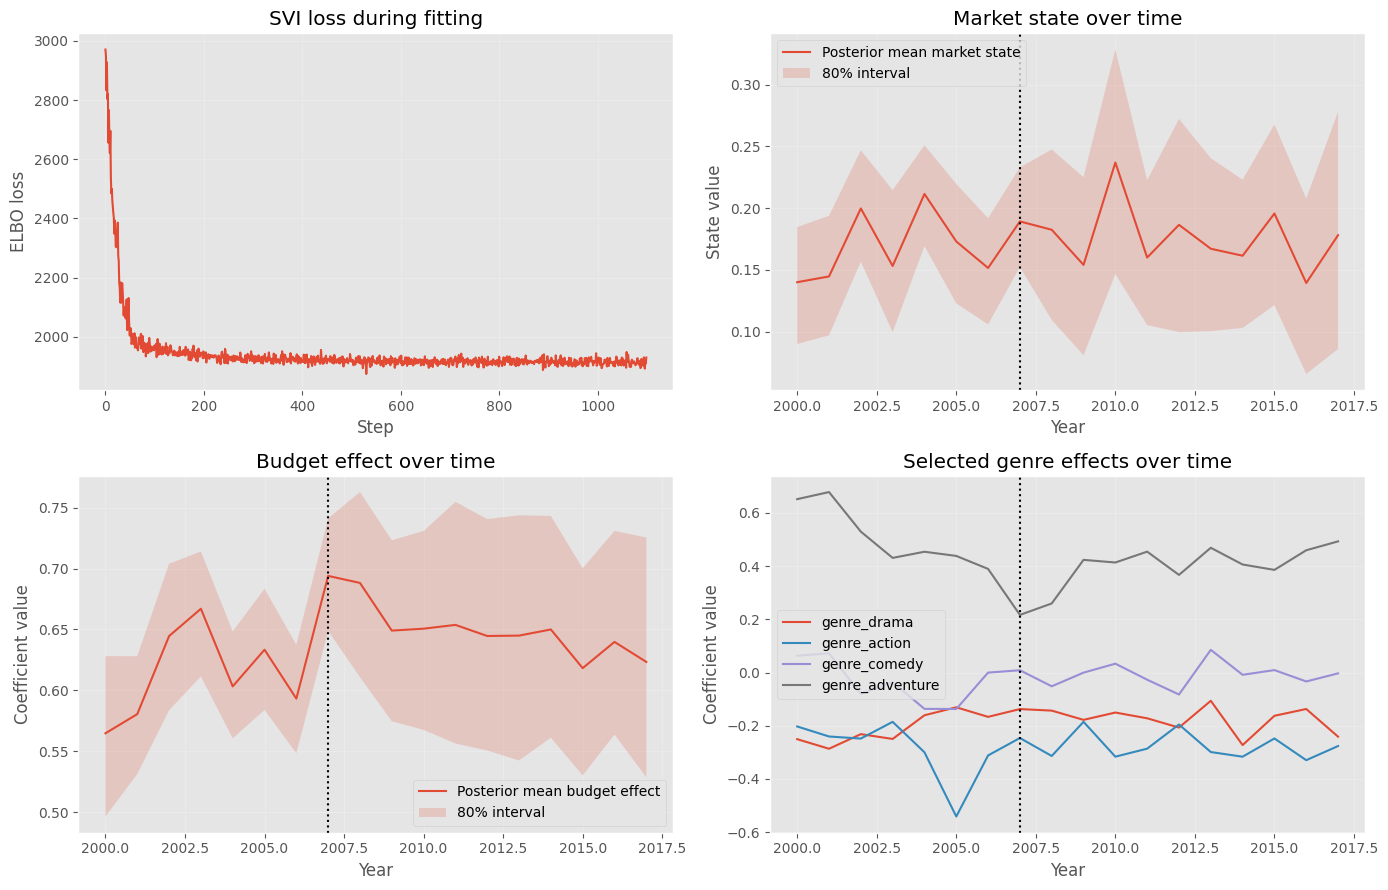

In [36]:
market_mean = market_path_samples.mean(axis=0)
market_low = np.quantile(market_path_samples, 0.1, axis=0)
market_high = np.quantile(market_path_samples, 0.9, axis=0)

beta_mean = beta_path_samples.mean(axis=0)
beta_low = np.quantile(beta_path_samples, 0.1, axis=0)
beta_high = np.quantile(beta_path_samples, 0.9, axis=0)

selected_genres = ['genre_drama', 'genre_action', 'genre_comedy', 'genre_adventure']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(losses)
axes[0, 0].set_title('SVI loss during fitting')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('ELBO loss')

axes[0, 1].plot(years, market_mean, label='Posterior mean market state')
axes[0, 1].fill_between(years, market_low, market_high, alpha=0.2, label='80% interval')
axes[0, 1].axvline(train_df['year'].max(), color='black', linestyle=':')
axes[0, 1].set_title('Market state over time')
axes[0, 1].set_xlabel('Year')
axes[0, 1].legend()

budget_idx = DYNAMIC_COLUMNS.index('budget_inflated_std')
axes[1, 0].plot(years, beta_mean[:, budget_idx], label='Posterior mean budget effect')
axes[1, 0].fill_between(years, beta_low[:, budget_idx], beta_high[:, budget_idx], alpha=0.2, label='80% interval')
axes[1, 0].axvline(train_df['year'].max(), color='black', linestyle=':')
axes[1, 0].set_title('Budget effect over time')
axes[1, 0].set_xlabel('Year')
axes[1, 0].legend()

for name in selected_genres:
    idx = DYNAMIC_COLUMNS.index(name)
    axes[1, 1].plot(years, beta_mean[:, idx], label=name)
axes[1, 1].axvline(train_df['year'].max(), color='black', linestyle=':')
axes[1, 1].set_title('Selected genre effects over time')
axes[1, 1].set_xlabel('Year')
axes[1, 1].legend(loc='best')

for ax in axes.ravel():
    ax.grid(alpha=0.2)

axes[0, 1].set_ylabel('State value')
axes[1, 0].set_ylabel('Coefficient value')
axes[1, 1].set_ylabel('Coefficient value')

plt.tight_layout()
plt.show()


### Converting to the Aggregation Target

This is the most important notebook-specific step. Internally, the model predicts `revenue_inflated`, but the group wants predictions on **nominal `revenue`**.

For the aggregation output, we use posterior samples of the model's **predictive mean** rather than noisy observation draws. This gives a more stable revenue-space summary when we transform back from the inflation-adjusted revenue scale.

We therefore convert each sampled predictive mean in two steps:

1. treat the sampled predictive mean as inflated revenue
2. divide by the movie-year inflation factor to get nominal revenue

Only after this sample-by-sample conversion do we compute the predictive mean and predictive standard deviation. This keeps the exported summary aligned with the Bayesian model while remaining directly usable in the group aggregation notebook.

The final CSV contains one row per movie in the shared test file, together with predictive mean, predictive standard deviation, and precision. This is the file that should be used in the group aggregation notebook.


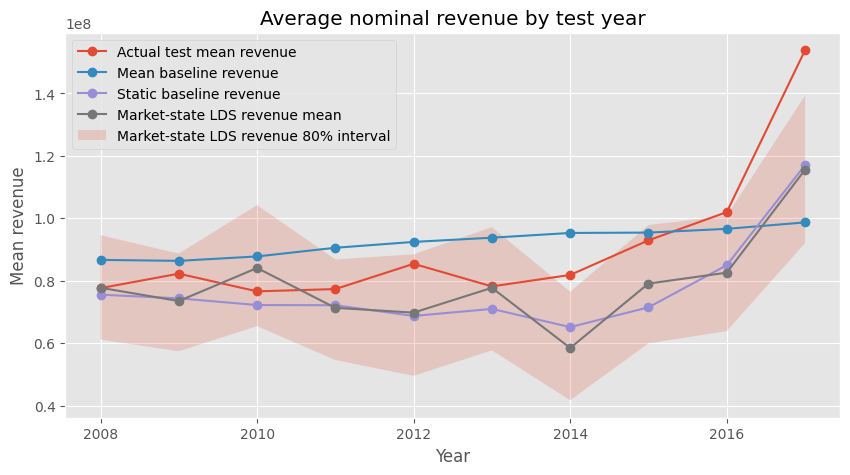

min predicted std: 12578538.155105986
max predicted std: 104817988.0633219


,year,actual_mean_revenue,mean_baseline_revenue,static_baseline_revenue,market_lds_revenue_mean,market_lds_revenue_low,market_lds_revenue_high
0,2008,7.765123e+07,8.669911e+07,7.554934e+07,7.777610e+07,6.116372e+07,9.459620e+07
1,2009,8.228889e+07,8.638700e+07,7.438871e+07,7.352004e+07,5.744618e+07,8.873058e+07
2,2010,7.662475e+07,8.780374e+07,7.223543e+07,8.410286e+07,6.548498e+07,1.042295e+08
3,2011,7.735648e+07,9.057834e+07,7.217919e+07,7.134205e+07,5.461698e+07,8.684826e+07
4,2012,8.543854e+07,9.245331e+07,6.874518e+07,6.981120e+07,4.956577e+07,8.847875e+07
5,2013,7.820775e+07,9.380313e+07,7.100704e+07,7.775670e+07,5.772214e+07,9.718931e+07
6,2014,8.187652e+07,9.532274e+07,6.516810e+07,5.849164e+07,4.176120e+07,7.650093e+07
7,2015,9.296569e+07,9.543713e+07,7.151246e+07,7.911533e+07,5.997930e+07,9.784499e+07
8,2016,1.019996e+08,9.663964e+07,8.499843e+07,8.260804e+07,6.389437e+07,1.008487e+08
9,2017,1.538357e+08,9.869806e+07,1.170686e+08,1.155745e+08,9.206425e+07,1.393209e+08


In [37]:
test_ids = test_df["id"].to_numpy()
test_true_revenue = test_df["revenue"].to_numpy()
test_revenue_posterior_samples = test_revenue_samples
predicted_revenue_mean = test_pred_revenue_mean
predicted_revenue_std = test_pred_revenue_std
predicted_revenue_std_safe = np.maximum(predicted_revenue_std, 1e-8)
precision_market_lds = 1.0 / (predicted_revenue_std_safe ** 2)

test_years = np.sort(test_df["year"].unique())
yearly_rows = {year: np.where(test_df["year"].to_numpy() == year)[0] for year in test_years}

summary_rows = []
for year in test_years:
    idx = yearly_rows[year]
    yearly_pred_samples = test_revenue_posterior_samples[:, idx].mean(axis=1)
    summary_rows.append({
        'year': year,
        'actual_mean_revenue': test_df.loc[test_df['year'] == year, 'revenue'].mean(),
        'mean_baseline_revenue': mean_test_pred_revenue[test_df['year'].to_numpy() == year].mean(),
        'static_baseline_revenue': baseline_test_pred_revenue[test_df['year'].to_numpy() == year].mean(),
        'market_lds_revenue_mean': yearly_pred_samples.mean(),
        'market_lds_revenue_low': np.quantile(yearly_pred_samples, 0.1),
        'market_lds_revenue_high': np.quantile(yearly_pred_samples, 0.9),
    })

yearly_test_summary = pd.DataFrame(summary_rows)

plt.figure(figsize=(10, 5))
plt.plot(yearly_test_summary['year'], yearly_test_summary['actual_mean_revenue'], marker='o', label='Actual test mean revenue')
plt.plot(yearly_test_summary['year'], yearly_test_summary['mean_baseline_revenue'], marker='o', label='Mean baseline revenue')
plt.plot(yearly_test_summary['year'], yearly_test_summary['static_baseline_revenue'], marker='o', label='Static baseline revenue')
plt.plot(yearly_test_summary['year'], yearly_test_summary['market_lds_revenue_mean'], marker='o', label='Market-state LDS revenue mean')
plt.fill_between(yearly_test_summary['year'], yearly_test_summary['market_lds_revenue_low'], yearly_test_summary['market_lds_revenue_high'], alpha=0.2, label='Market-state LDS revenue 80% interval')
plt.title('Average nominal revenue by test year')
plt.xlabel('Year')
plt.ylabel('Mean revenue')
plt.legend()
plt.show()

export_columns = {
    'id': test_df['id'].to_numpy(),
    'year': test_df['year'].to_numpy(),
    'revenue': test_true_revenue,
    'predicted_revenue_mean': predicted_revenue_mean,
    'predicted_revenue_std': predicted_revenue_std,
    'precision_market_lds': precision_market_lds,
}
if 'title' in test_df.columns:
    export_columns['title'] = test_df['title'].to_numpy()


print('min predicted std:', float(predicted_revenue_std.min()))
print('max predicted std:', float(predicted_revenue_std.max()))

yearly_test_summary


### Notes

This notebook exports predictions on nominal `revenue`, even though the internal model is fitted on `revenue_inflated`.



## Model 4: Genre & Keywords → Revenue

Bayesian linear regression with ARD-style priors over genre one-hots and keyword topic features.  
Output: posterior predictive **N(μ_genre, σ_genre²)** over log-revenue per movie.

Pipeline:
1. Load movies + keywords
2. Parse keywords → TF-IDF → SVD topics
3. Build feature matrix: genres + topics + runtime
4. Pyro model with group-level ARD priors
5. SVI training
6. Posterior predictive → (μ, σ) per movie

In [38]:
import ast
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
DATA_DIR = Path('../data/')
N_KEYWORD_TOPICS = 20   # number of SVD latent topics extracted from keyword TF-IDF matrix
N_SVI_STEPS      = 3000 # total gradient steps for variational inference
LR               = 0.01 # learning rate for ClippedAdam optimizer


### 7. Pyro Model — ARD Bayesian Regression

Each feature group gets its own scale prior (ARD-style).  
High-σ group = more flexible = model trusts that group more.

```
σ_genre  ~ HalfNormal(5)
β_genre  ~ Normal(0, σ_genre)   [15 weights]

σ_kw     ~ HalfNormal(2)
β_kw     ~ Normal(0, σ_kw)      [20 weights]

β_runtime ~ Normal(0, 2)
intercept ~ Normal(14, 3)        [log-revenue ≈ 14–20]

σ_obs    ~ HalfNormal(1)

μ = intercept + X_genre @ β_genre + X_kw @ β_kw + X_runtime * β_runtime
log_revenue ~ Normal(μ, σ_obs)
```

In [39]:
# N_GENRE = X_genre.shape[1]   # 15
# N_KW    = X_kw.shape[1]      # 20

# def model(X_genre, X_kw, X_runtime, y=None):
#     n = X_genre.shape[0]

#     # Global intercept centred on typical log-revenue (~14–20 range)
#     intercept  = pyro.sample("intercept",  dist.Normal(14., 3.))

#     # ARD-style prior for genre weights:
#     # sigma_genre is shared across all 15 genre betas — it controls how much the model
#     # trusts genre information overall. If sigma_genre is large, genre betas can be large.
#     sigma_genre = pyro.sample("sigma_genre", dist.HalfNormal(5.))
#     beta_genre  = pyro.sample("beta_genre",
#                               dist.Normal(torch.zeros(N_GENRE),
#                                           sigma_genre * torch.ones(N_GENRE)).to_event(1))

#     # ARD-style prior for keyword topic weights (tighter prior than genre — HalfNormal(2))
#     sigma_kw = pyro.sample("sigma_kw", dist.HalfNormal(2.))
#     beta_kw  = pyro.sample("beta_kw",
#                            dist.Normal(torch.zeros(N_KW),
#                                        sigma_kw * torch.ones(N_KW)).to_event(1))

#     # Runtime gets a simple fixed prior — less domain uncertainty here
#     beta_runtime = pyro.sample("beta_runtime", dist.Normal(0., 2.))

#     # Observation noise — how much unexplained variance remains after all features
#     sigma_obs = pyro.sample("sigma_obs", dist.HalfNormal(1.))

#     # Linear predictor: intercept + genre contribution + keyword contribution + runtime
#     mu = (intercept
#           + X_genre   @ beta_genre
#           + X_kw      @ beta_kw
#           + X_runtime.squeeze(-1) * beta_runtime)

#     # Likelihood: each movie's log-revenue is Normal around the linear predictor
#     with pyro.plate("data", n):
#         pyro.sample("obs", dist.Normal(mu, sigma_obs), obs=y)

### 8. SVI Training

In [40]:
# pyro.clear_param_store()  # reset any leftover variational parameters from previous runs

# # AutoNormal automatically creates one variational mean + variance per latent variable
# guide = AutoNormal(model)

# # ClippedAdam: standard Adam but gradients are clipped to prevent exploding updates
# optimizer = ClippedAdam({"lr": LR, "clip_norm": 5.0})

# # SVI minimises the negative ELBO = KL(q||p) - E_q[log p(data|θ)]
# # Maximising ELBO = fitting the data well + keeping posteriors close to priors
# svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# losses = []
# print(f"Training SVI for {N_SVI_STEPS} steps...")
# for step in range(N_SVI_STEPS):
#     loss = svi.step(Xg_tr, Xk_tr, Xr_tr, y_tr)  # one gradient step on the full training set
#     losses.append(loss)
#     if step % 500 == 0:
#         print(f"  step {step:4d}  ELBO loss: {loss:.2f}")

# print("Done.")

In [41]:
# plt.figure(figsize=(10, 3))
# plt.plot(losses)
# plt.xlabel("SVI Step")
# plt.ylabel("ELBO Loss")
# plt.title("Model 4: SVI Convergence")
# plt.tight_layout()
# plt.show()

### 9. Posterior Predictive — Output N(μ, σ²)

In [42]:
# N_SAMPLES = 500  # number of posterior samples drawn to approximate the predictive distribution

# # Predictive draws N_SAMPLES sets of parameters from the guide (variational posterior),
# # then runs the model forward to get a distribution over log-revenue
# predictive = Predictive(model, guide=guide, num_samples=N_SAMPLES,
#                         return_sites=["obs", "sigma_genre", "sigma_kw",
#                                       "beta_genre", "beta_kw",
#                                       "intercept", "sigma_obs"])

# # Run posterior predictive on train and test sets (no gradient needed at inference time)
# with torch.no_grad():
#     post_tr = predictive(Xg_tr, Xk_tr, Xr_tr)
#     post_te = predictive(Xg_te, Xk_te, Xr_te)

# # obs shape: (N_SAMPLES, n_movies) — average over samples to get point estimate and uncertainty
# mu_tr = post_tr["obs"].mean(0).numpy()   # posterior predictive mean per training movie
# sd_tr = post_tr["obs"].std(0).numpy()    # posterior predictive std  per training movie

# mu_te = post_te["obs"].mean(0).numpy()   # posterior predictive mean per test movie
# sd_te = post_te["obs"].std(0).numpy()    # posterior predictive std  per test movie


# y_mean_model4_test=mu_te
# y_mean_model4_train=mu_tr
# y_std_model4_test=sd_te
# y_std_model4_train=sd_tr

# print("Posterior predictive computed.")
# print(f"Test  μ range: [{mu_te.min():.2f}, {mu_te.max():.2f}]")
# print(f"Test  σ range: [{sd_te.min():.3f}, {sd_te.max():.3f}]")

### 10. Evaluate — RMSE on log-revenue

In [43]:
# rmse_train = np.sqrt(np.mean((mu_tr - y_tr.numpy())**2))
# rmse_test  = np.sqrt(np.mean((mu_te - y_te.numpy())**2))

# # Log-likelihood measures how well the model's full distribution (not just mean) fits the data
# # Higher = better; accounts for both accuracy (μ) and calibration (σ)
# from scipy.stats import norm
# log_lik = norm.logpdf(y_te.numpy(), loc=mu_te, scale=sd_te).mean()

# print(f"RMSE (log-revenue) — Train : {rmse_train:.4f}")
# print(f"RMSE (log-revenue) — Test  : {rmse_test:.4f}")
# print(f"Mean log-likelihood (test) : {log_lik:.4f}")

In [44]:
# fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# # Predicted vs actual
# ax = axes[0]
# ax.scatter(y_te.numpy(), mu_te, alpha=0.3, s=12, color='steelblue')
# lo, hi = y_te.numpy().min(), y_te.numpy().max()
# ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='perfect')
# ax.set_xlabel("Actual log-revenue")
# ax.set_ylabel("Predicted μ")
# ax.set_title(f"Model 4: Predicted vs Actual  (RMSE={rmse_test:.3f})")
# ax.legend()

# # Uncertainty distribution
# ax = axes[1]
# ax.hist(sd_te, bins=40, color='coral', edgecolor='white')
# ax.set_xlabel("Predictive σ (log-revenue)")
# ax.set_ylabel("Count")
# ax.set_title("Predictive Uncertainty per Movie")

# plt.tight_layout()
# plt.show()

### 11. What Did the Model Learn? — Genre Weights

In [45]:
# # Extract genre weight samples from the posterior predictive object — shape (N_SAMPLES, N_GENRE)
# beta_genre_samples = post_te["beta_genre"].numpy()

# # Baseline = training mean revenue (2024 USD)
# # exp(mean log-revenue) = geometric mean revenue of training movies
# baseline_revenue = np.exp(y_tr.numpy().mean())
# print(f"Training baseline revenue: ${baseline_revenue/1e6:.1f}M")

# # Convert log-revenue betas → dollar effect relative to baseline
# # If log-revenue changes by β, revenue changes by baseline * (exp(β) - 1)
# # Transform each posterior sample so uncertainty propagates correctly
# revenue_effect_samples = baseline_revenue * (np.exp(beta_genre_samples) - 1)  # (N_SAMPLES, N_GENRE)
# revenue_effect_mean = revenue_effect_samples.mean(0).flatten()   # posterior mean $ effect per genre
# revenue_effect_std  = revenue_effect_samples.std(0).flatten()    # posterior std  $ effect per genre

# genre_weight_df = pd.DataFrame({
#     'genre'         : TOP_GENRES,
#     'mean_β'        : beta_genre_samples.mean(0).flatten(),      # keep raw β for reference
#     'revenue_effect': revenue_effect_mean,
#     'revenue_std'   : revenue_effect_std,
#     'lower'         : revenue_effect_mean - 2 * revenue_effect_std,
#     'upper'         : revenue_effect_mean + 2 * revenue_effect_std,
# }).sort_values('revenue_effect', ascending=True)

# fig, ax = plt.subplots(figsize=(8, 6))
# colors = ['green' if m > 0 else 'red' for m in genre_weight_df['revenue_effect']]
# # Error bars show ±2σ in revenue space — if bar crosses 0, that genre's effect is uncertain
# ax.barh(genre_weight_df['genre'], genre_weight_df['revenue_effect'] / 1e6,
#         xerr=2 * genre_weight_df['revenue_std'] / 1e6, color=colors, alpha=0.7,
#         capsize=4, ecolor='gray')
# ax.axvline(0, color='black', lw=1)
# ax.set_xlabel(f"Revenue effect vs baseline (${baseline_revenue/1e6:.0f}M train mean)  [$ millions]")
# ax.set_title("Model 4: Posterior Genre Revenue Effects (±2σ)")
# plt.tight_layout()
# plt.show()

# genre_weight_df[['genre', 'revenue_effect', 'revenue_std', 'lower', 'upper']].assign(
#     **{c: genre_weight_df[c] / 1e6 for c in ['revenue_effect', 'revenue_std', 'lower', 'upper']}
# ).rename(columns=lambda c: c + '_$M' if c != 'genre' else c)

### 12. Keyword Topic Weights

In [46]:
# # Extract keyword topic weight samples — shape (N_SAMPLES, N_KW)
# beta_kw_samples = post_te["beta_kw"].numpy()
# beta_kw_mean = beta_kw_samples.mean(0).flatten()
# beta_kw_std  = beta_kw_samples.std(0).flatten()

# # Show top 5 keywords per SVD topic so we can interpret what each topic represents
# feature_names = tfidf.get_feature_names_out()
# components = svd.components_   # shape (N_KW, vocab_size) — each row is one topic

# print("Top keywords per topic:")
# for i in range(N_KEYWORD_TOPICS):
#     top_kw = [feature_names[j] for j in components[i].argsort()[-5:][::-1]]
#     sign   = "+" if beta_kw_mean[i] > 0 else "-"
#     # β sign tells whether this topic's presence helps (+) or hurts (-) predicted revenue
#     print(f"  Topic {i:2d} [{sign} β={beta_kw_mean[i]:+.3f}]: {', '.join(top_kw)}")

In [47]:
# kw_topic_labels = [f"T{i}" for i in range(N_KEYWORD_TOPICS)]

# kw_weight_df = pd.DataFrame({
#     'topic'  : kw_topic_labels,
#     'mean_β' : beta_kw_mean,
#     'std_β'  : beta_kw_std,
# }).sort_values('mean_β', ascending=True)

# fig, ax = plt.subplots(figsize=(8, 6))
# colors = ['green' if m > 0 else 'red' for m in kw_weight_df['mean_β']]
# ax.barh(kw_weight_df['topic'], kw_weight_df['mean_β'],
#         xerr=2 * kw_weight_df['std_β'], color=colors, alpha=0.7,
#         capsize=4, ecolor='gray')
# ax.axvline(0, color='black', lw=1)
# ax.set_xlabel("β (effect on log-revenue)")
# ax.set_title("Model 4: Posterior Keyword Topic Weights (±2σ)")
# plt.tight_layout()
# plt.show()

### 13. Export Posterior Predictive — N(μ, σ²) per Movie

This is the output fed into the Bayesian aggregator (precision-weighted fusion).

In [48]:
# # Run posterior predictive on ALL 5190 movies (not just train/test split)
# # This full-dataset output is what gets fed into the Bayesian aggregator
# Xg_all = torch.tensor(X_genre)
# Xk_all = torch.tensor(X_kw)
# Xr_all = torch.tensor(X_runtime)

# with torch.no_grad():
#     post_all = predictive(Xg_all, Xk_all, Xr_all)

# mu_all = post_all["obs"].mean(0).numpy()   # posterior predictive mean per movie
# sd_all = post_all["obs"].std(0).numpy()    # posterior predictive std  per movie

# model4_output = pd.DataFrame({
#     'id'            : movies['id'].values,
#     'title'         : movies['title'].values,
#     'log_revenue'   : movies['log_revenue'].values,
#     'mu_genre'      : mu_all,
#     'sigma_genre'   : sd_all,
#     # precision = 1/σ² — used as weight in the precision-weighted Bayesian fusion formula
#     # higher precision = model is more confident = gets more weight in aggregation
#     'precision_genre': 1.0 / (sd_all ** 2),
# })

# model4_output.to_csv(DATA_DIR / 'model4_posterior.csv', index=False)
# print(f"Saved model4_posterior.csv — {model4_output.shape[0]} movies")
# model4_output.head(10)

### 14. Summary

| Output | Meaning |
|--------|----------|
| `mu_genre` | Posterior mean log-revenue prediction from genre+keywords |
| `sigma_genre` | Posterior std — uncertainty of this model |
| `precision_genre` | `1/σ²` — weight in precision-weighted Bayesian fusion |

**Aggregator formula (product of experts):**
```
σ_agg² = 1 / Σ_i (1/σ_i²)
μ_agg  = σ_agg² · Σ_i (μ_i / σ_i²)
```
Model 4 contributes one term. High σ_genre → low weight in aggregation → model self-reports low confidence.

# Agregation Model

In [49]:
y_mean_model3_test = torch.tensor(y_mean_model3_test)
y_mean_model3_train = torch.tensor(y_mean_model3_train)
y_std_model3_test = torch.tensor(y_std_model3_test)
y_std_model3_train = torch.tensor(y_std_model3_train)

In [50]:
#test
y_means_test = [y_mean_model1_test, y_mean_model2_test,y_mean_model3_test]
y_stds_test = [y_std_model1_test, y_std_model2_test,y_std_model3_test]
#y_std_model4_test
#y_mean_model4_test

y_means_tensor_test = torch.stack(y_means_test, dim=1)
y_stds_tensor_test = torch.stack(y_stds_test, dim=1)
combined_data_test=torch.cat([y_means_tensor_test, y_stds_tensor_test], dim=1)
print("test data")
print(y_means_tensor_test.shape)
print(y_stds_tensor_test.shape)
print(combined_data_test.shape)

#train
y_means_train = [y_mean_model1_train, y_mean_model2_train, y_mean_model3_train]
y_stds_train = [y_std_model1_train, y_std_model2_train, y_std_model3_train]

#y_std_model4_train
#y_mean_model4_train

y_means_tensor_train = torch.stack(y_means_train, dim=1)
y_stds_tensor_train = torch.stack(y_stds_train, dim=1)
combined_data_train=torch.cat([y_means_tensor_train, y_stds_tensor_train], dim=1)


print("train data")
print(y_means_tensor_train.shape)
print(y_stds_tensor_train.shape)
print(combined_data_train.shape)




test data
torch.Size([2846, 3])
torch.Size([2846, 3])
torch.Size([2846, 6])
train data
torch.Size([1706, 3])
torch.Size([1706, 3])
torch.Size([1706, 6])


In [51]:
def agregate_predictions(x,  obs=None):
    alpha = pyro.sample("alpha", dist.Normal(0, 1))
    beta = pyro.sample("beta", dist.Normal(torch.zeros(x.shape[1]), torch.ones(x.shape[1])).to_event(1))
    sigma = pyro.sample("sigma", dist.HalfCauchy(1.0))
    with pyro.plate("data", x.shape[0]):
        y = pyro.sample("y", dist.Normal(alpha + x.matmul(beta), sigma), obs=obs)
    return y

In [52]:

# Clear parameter store
pyro.clear_param_store()

# Define guide function
guide_aggregate = AutoNormal(agregate_predictions)

# Define optimizer
optimizer = Adam({"lr": 0.01})

# Define SVI
svi_aggregate = SVI(
    agregate_predictions,
    guide_aggregate,
    optimizer,
    loss=Trace_ELBO()
)

# Number of steps for optimization
num_steps = 2000

# Train the model
for step in range(num_steps):
    loss = svi_aggregate.step(combined_data_train, y_train_torch)
    if step % 100 == 0:
        print(f"Step {step} - Loss: {loss:.2f}")

RuntimeError: expected scalar type Double but found Float
Trace Shapes:    
 Param Sites:    
Sample Sites:    
   alpha dist |  
        value |  
    beta dist | 6
        value | 6
   sigma dist |  
        value |  
Trace Shapes:
 Param Sites:
Sample Sites:

In [ ]:


# Use Predictive to make predictions
predictive_aggregate = Predictive(
    agregate_predictions,
    guide=guide_aggregate,
    num_samples=500,
    return_sites=("alpha", "beta", "sigma", "y")
)

# Generate posterior samples for the test data
posterior_samples_aggregate = predictive_aggregate(combined_data_test)

# Extract mean and standard deviation of predictions
y_samples_aggregate = posterior_samples_aggregate["y"]
y_mean_aggregate = y_samples_aggregate.mean(dim=0)
y_std_aggregate = y_samples_aggregate.std(dim=0)

# Print the shape of predictions
print("Predicted mean shape:", y_mean_aggregate.shape)
print("Predicted std shape:", y_std_aggregate.shape)

Predicted mean shape: torch.Size([2846])
Predicted std shape: torch.Size([2846])


In [ ]:
# True values
y_true = y_test_torch

# Model metrics
model_mae = torch.mean(torch.abs(y_mean_aggregate - y_true))
model_rmse = torch.sqrt(torch.mean((y_mean_aggregate - y_true) ** 2))

# Baseline: predict 0 for every occurrence
baseline_pred = torch.full_like(y_true, y_train_torch.mean())

baseline_mae = torch.mean(torch.abs(baseline_pred - y_true))
baseline_rmse = torch.sqrt(torch.mean((baseline_pred - y_true) ** 2))

# Improvement
mae_improvement = baseline_mae - model_mae
rmse_improvement = baseline_rmse - model_rmse

mae_improvement_pct = 100 * mae_improvement / baseline_mae
rmse_improvement_pct = 100 * rmse_improvement / baseline_rmse

print("Aggregated Model MAE:", model_mae.item())
print("Baseline MAE:", baseline_mae.item())
print("MAE improvement:", mae_improvement.item())
print("MAE improvement %:", mae_improvement_pct.item())

print()

print("Aggregated Model RMSE:", model_rmse.item())
print("Baseline RMSE:", baseline_rmse.item())
print("RMSE improvement:", rmse_improvement.item())
print("RMSE improvement %:", rmse_improvement_pct.item())

Aggregated Model MAE: 0.3785409927368164
Baseline MAE: 0.6591777801513672
MAE improvement: 0.2806367874145508
MAE improvement %: 42.57376480102539

Aggregated Model RMSE: 0.7465318441390991
Baseline RMSE: 1.12571382522583
RMSE improvement: 0.37918198108673096
RMSE improvement %: 33.683692932128906


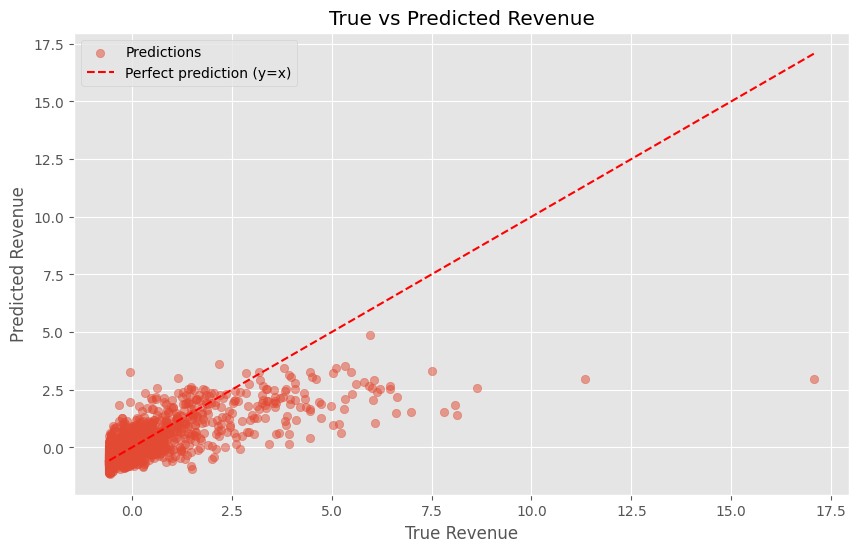

In [ ]:
# Plot true vs predicted revenue with regression line
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_mean_aggregate, alpha=0.5, label='Predictions')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Perfect prediction (y=x)')
plt.xlabel('True Revenue')
plt.ylabel('Predicted Revenue')
plt.title('True vs Predicted Revenue')
plt.legend()
plt.show()